# ESTIA advanced data reduction

- Audience: Instrument (data) scientists, instrument users
- Prerequisites: Basic knowledge of [Scipp](https://scipp.github.io/), [Sciline](https://scipp.github.io/sciline/)

This notebook builds on the [basic ESTIA reduction guide](./estia-mcstas-reduction.rst); you should read that first.
This advanced guide demonstrates how the workflow can be used to make diagnostics plots and options for processing multiple files together.
This example also shows how to replace the default loader with the `load_mcstas_events` provider.

The data is available through the ESSreflectometry package but accessing it requires the pooch package.
If you get an error about a missing module pooch, you can install it with `!pip install pooch`.

In [1]:
from typing import NewType

import scipp as sc

from ess.estia import data
from ess.estia import EstiaMcStasWorkflow
from ess.reflectometry.types import *
from ess.reflectometry.figures import wavelength_z_figure, wavelength_theta_figure, q_theta_figure
from ess.reflectometry.tools import batch_compute

## Process multiple files

To apply the ESTIA workflow to multiple files, we could simply write a for-loop like this:
```python
results = []
for filename in data.estia_mcstas_sample_example('Ni/Ti-multilayer'):
    wf[Filename[SampleRun]] = filename
    results.append(wf.compute(ReflectivityOverQ))
```
However, this would re-load and re-process the reference measurement for every sample file.
Instead, we will use the batch-compute feature to map the workflow over several files.

First, we set up the workflow in almost the same way as in the [basic ESTIA reduction guide](./estia-mcstas-reduction.rst), except that we do *not* set a filename for the sample run.

In [2]:
wf = EstiaMcStasWorkflow()
wf[Filename[ReferenceRun]] = data.estia_mcstas_reference_example()

wf[YIndexLimits] = sc.scalar(35), sc.scalar(64)
wf[ZIndexLimits] = sc.scalar(0), sc.scalar(48 * 32)
wf[BeamDivergenceLimits] = sc.scalar(-0.75, unit='deg'), sc.scalar(0.75, unit='deg')

wf[WavelengthBins] = sc.geomspace('wavelength', 3.5, 12, 2001, unit='angstrom')
wf[QBins] = sc.geomspace('Q', 0.01, 0.5, 401, unit='1/angstrom')

# If you want to use the ground truth wavelengths from the McStas simulation
# instead of the wavelengths from the frame unwrapping, uncomment the lines below:
#from ess.estia.mcstas import use_mcstas_wavelengths_instead_of_estimates_from_time_of_arrival
#wf.insert( use_mcstas_wavelengths_instead_of_estimates_from_time_of_arrival )
wf[LookupTableFilename] = data.estia_wavelength_lookup_table()
# Set the wavalength relative error threshold for when to exclude events
# because the uncertainty in wavelength is too large.
# Here it is set to 4%.
wf[LookupTableRelativeErrorThreshold] = {'multiblade_detector': 0.04}

# There is no proton charge data in the McStas files, here we just add some fake proton charge
# data to make the workflow run.
wf[ProtonCharge[SampleRun]] = sc.DataArray(
    sc.array(dims=('time',), values=[], unit='uC'),
    coords={'time': sc.array(dims=('time',), values=[], unit='s')})
wf[ProtonCharge[ReferenceRun]] = sc.DataArray(
    sc.array(dims=('time',), values=[], unit='uC'),
    coords={'time': sc.array(dims=('time',), values=[], unit='s')})

## Reflectivity vs. Q

In this section, we compute the reflectivity as a function of momentum transfer for a number of files with the same sample at different sample rotations.

First we will take a look at the workflow graph, note that the file name is not yet set:

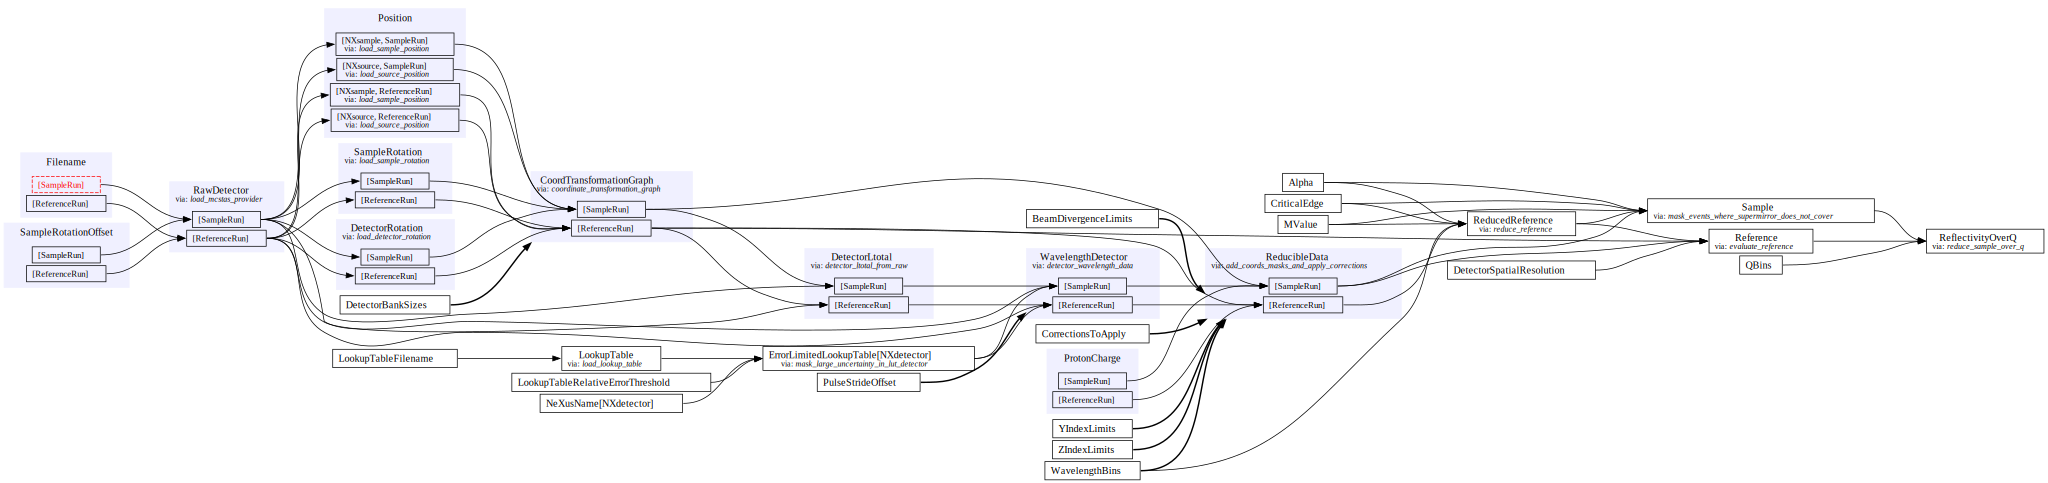

In [3]:
wf.visualize(
    ReflectivityOverQ,
    graph_attr={"rankdir": "LR"},
    compact=True,
)

We compute the reflectivity for each file and make a data group:

In [4]:
runs = [
    {Filename[SampleRun]: fname}
    for fname in data.estia_mcstas_sample_example('Ni/Ti-multilayer')
]

reflectivities = sc.DataGroup({
    f"{da.coords['sample_rotation']:c}": da
    for da in batch_compute(wf, runs, ReflectivityOverQ)
})

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/matplotlib/axes/_axes.py:3831: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


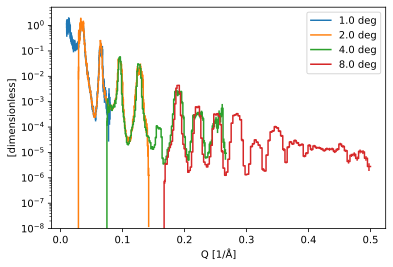

In [5]:
reflectivities.hist().plot(norm='log', vmin=1e-8)

### Reflectivity vs. Q with custom mask

The data is very noisy in some $Q$ bins.
We can clean up the plot by removing or masking those bins.
The variance of the reference measurement is a good measure for how noisy the final data will be, so we use that to insert a mask into the reflectivity curve.
This means that we need to request `Reference` to construct the mask.
But since the value of `Reference` is different for each sample run, we need to insert a new step into the workflow.
See also [Replacing providers](https://scipp.github.io/sciline/recipes/replacing-providers.html) for a more general guide.

We define a custom type (`MaskedReflectivityOverQ`) and a provider to apply the mask:

In [6]:
MaskedReflectivityOverQ = NewType('MaskedReflectivityOverQ', sc.DataArray)


def mask_noisy_reference(
        reflectivity: ReflectivityOverQ,
        reference: Reference,
) -> MaskedReflectivityOverQ:
    ref = reference.hist(Q=reflectivity.coords['Q'])
    return reflectivity.assign_masks(
        noisy_reference=sc.stddevs(ref).data > 0.3 * ref.data
    )


wf.insert(mask_noisy_reference)

The graph is the same as before except that only `MaskedReflectivityOverQ` is available as a final type:

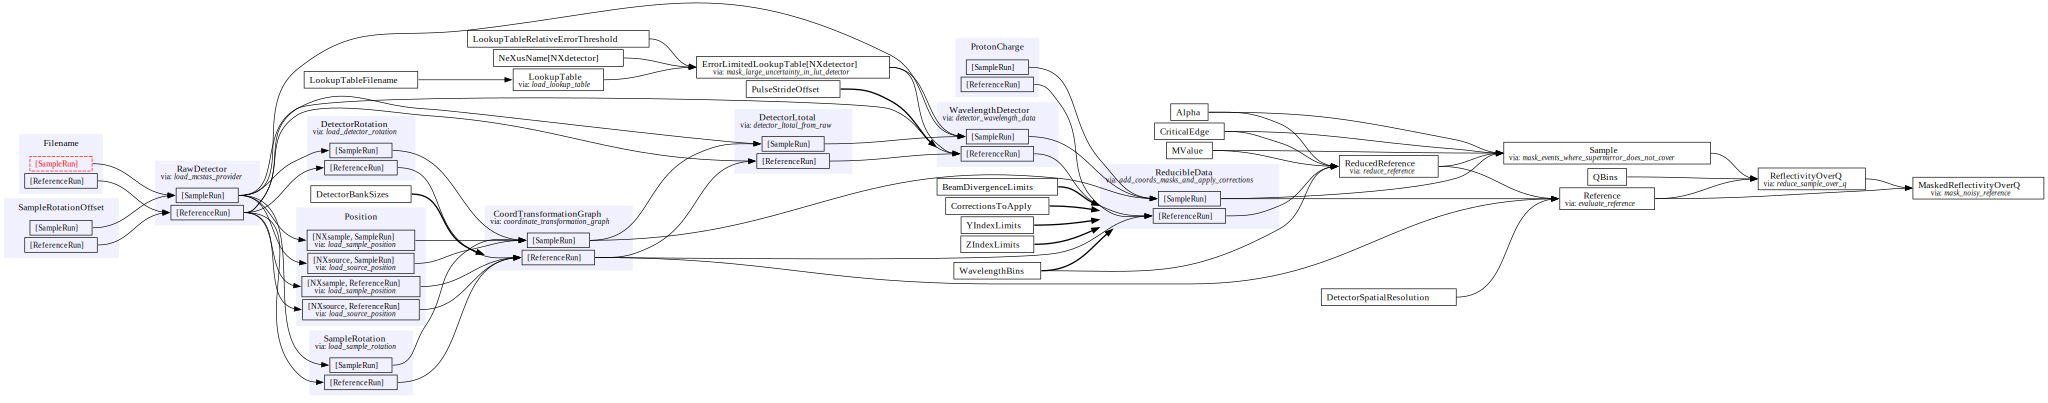

In [7]:
wf.visualize(
    MaskedReflectivityOverQ,
    graph_attr={"rankdir": "LR"},
    compact=True,
)

Compute the results:

In [8]:
reflectivities = sc.DataGroup({
    f"{da.coords['sample_rotation']:c}": da
    for da in batch_compute(wf, runs, MaskedReflectivityOverQ)
})

To plot, we histogram and set values in masked bins to NaN to make the plot easier to read:

In [9]:
histograms = reflectivities.hist().apply(lambda R: R.assign(
    sc.where(
        R.masks['noisy_reference'],
        sc.scalar(float('nan'), unit=R.unit),
        R.data,
    )
))

Since this data is from a McStas simulation, we know the true reflectivity of the sample.
We plot it alongside the 'measured' reflectivity for comparison:

/home/runner/work/ess/ess/.pixi/envs/docs-essreflectometry/lib/python3.11/site-packages/matplotlib/axes/_axes.py:3831: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


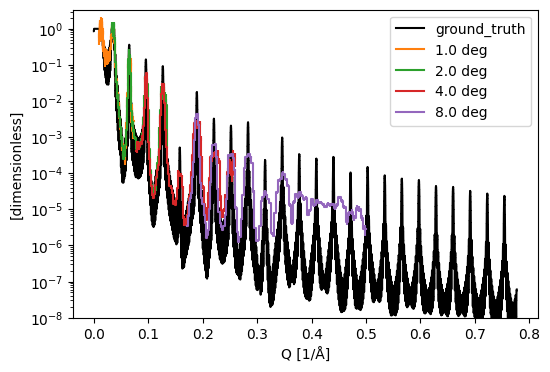

In [10]:
ground_truth = data.estia_mcstas_groundtruth('Ni/Ti-multilayer')
sc.plot({'ground_truth': ground_truth} | dict(histograms), norm='log', vmin=1e-8, c={'ground_truth': 'k'})

### Other projections

ESSreflectometry provides functions for plotting the intensity as a function of different variables.
Note that these plots can also be produced by the workflow directly, see [Draw diagnostics plots with the workflow](#Draw-diagnostics-plots-with-the-workflow).
But here, we make them manually to combine data from all files in the figures.

The plots consume data that is provided by the `Sample` key in the workflow.

In [11]:
results = batch_compute(wf, runs, Sample)

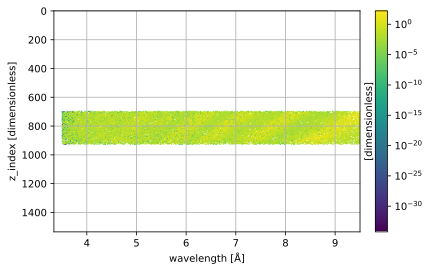

In [12]:
wavelength_z_figure(results[3], wavelength_bins=400)

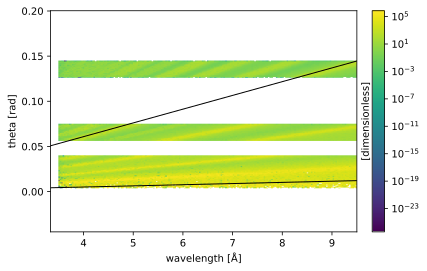

In [13]:
wavelength_theta_figure(
    results,
    wavelength_bins=200,
    theta_bins=200,
    q_edges_to_display=[sc.scalar(0.016, unit='1/angstrom'), sc.scalar(0.19, unit='1/angstrom')]
)

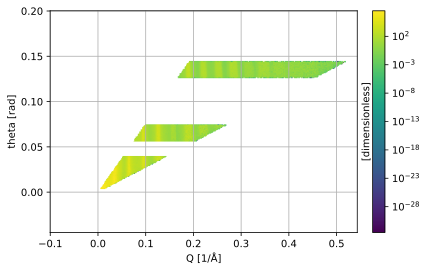

In [14]:
q_theta_figure(results, q_bins=200, theta_bins=200)

## Draw diagnostics plots with the workflow

The ESTIA workflow can produce a number of plots directly to quickly visualize the data in different forms.
Those plots can be combined into a single `ReflectivityDiagnosticsView` or constructed separately.
Here, we use the combined `ReflectivityDiagnosticsView` but you can also request one or more of the individual views (see also the graph below):
- `ReflectivityOverQ`
- `ReflectivityOverZW`
- `WavelengthThetaFigure`
- `WavelengthZIndexFigure`

These plots correspond to the figures in the [Other projections](#Other-projections) sections above but show only data from a single file.

We construct the workflow as in the [basic ESTIA reduction guide](./estia-mcstas-reduction.rst) but also add `ThetaBins` for the sample run to control the plots:

In [15]:
wf = EstiaMcStasWorkflow()
wf[Filename[SampleRun]] = data.estia_mcstas_sample_example('Ni/Ti-multilayer')[3]
wf[Filename[ReferenceRun]] = data.estia_mcstas_reference_example()

wf[YIndexLimits] = sc.scalar(35), sc.scalar(64)
wf[ZIndexLimits] = sc.scalar(0), sc.scalar(48 * 32)
wf[BeamDivergenceLimits] = sc.scalar(-0.75, unit='deg'), sc.scalar(0.75, unit='deg')

wf[WavelengthBins] = sc.geomspace('wavelength', 3.5, 12, 201, unit='angstrom')
wf[ThetaBins[SampleRun]] = 200
wf[QBins] = sc.geomspace('Q', 0.15, 0.5, 401, unit='1/angstrom')

# If you want to use the ground truth wavelengths from the McStas simulation
# instead of the wavelengths from the frame unwrapping, uncomment the lines below:
#from ess.estia.mcstas import use_mcstas_wavelengths_instead_of_estimates_from_time_of_arrival
#wf.insert( use_mcstas_wavelengths_instead_of_estimates_from_time_of_arrival )
wf[LookupTableFilename] = data.estia_wavelength_lookup_table()

# There is no proton charge data in the McStas files, here we just add some fake proton charge
# data to make the workflow run.
wf[ProtonCharge[SampleRun]] = sc.DataArray(
    sc.array(dims=('time',), values=[], unit='uC'),
    coords={'time': sc.array(dims=('time',), values=[], unit='s')})
wf[ProtonCharge[ReferenceRun]] = sc.DataArray(
    sc.array(dims=('time',), values=[], unit='uC'),
    coords={'time': sc.array(dims=('time',), values=[], unit='s')})

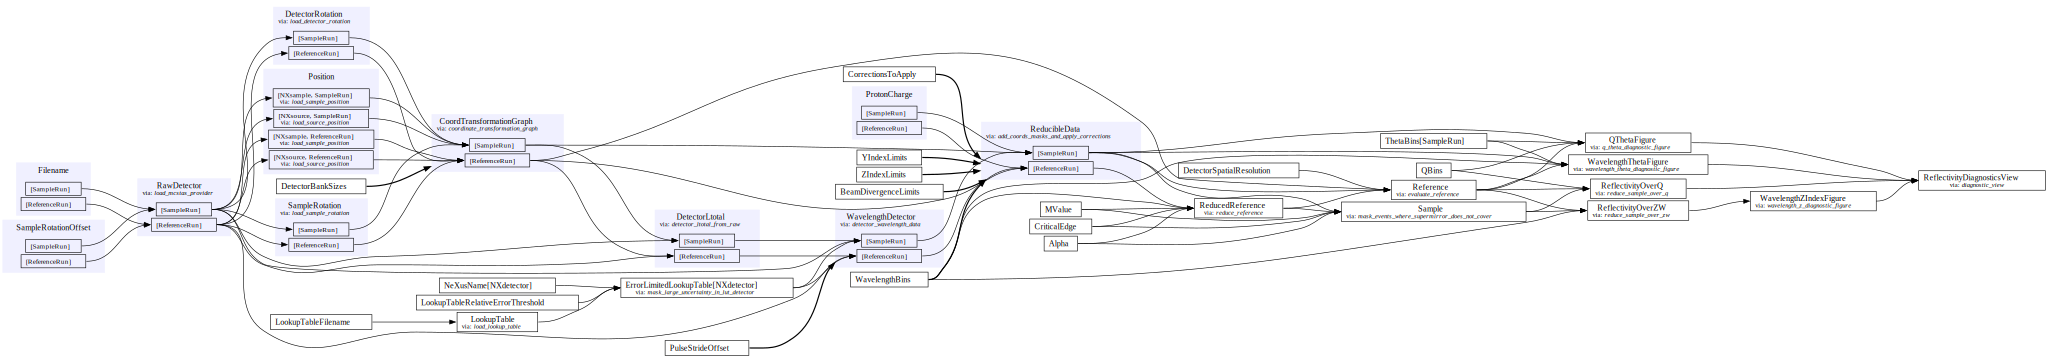

In [16]:
wf.visualize(ReflectivityDiagnosticsView, graph_attr={'rankdir': 'LR'})

We request the figure like any other data in the workflow:

In [17]:
view = wf.compute(ReflectivityDiagnosticsView)

And finally, we draw it: (this `view` object can be rendered in a Jupyter notebook.)

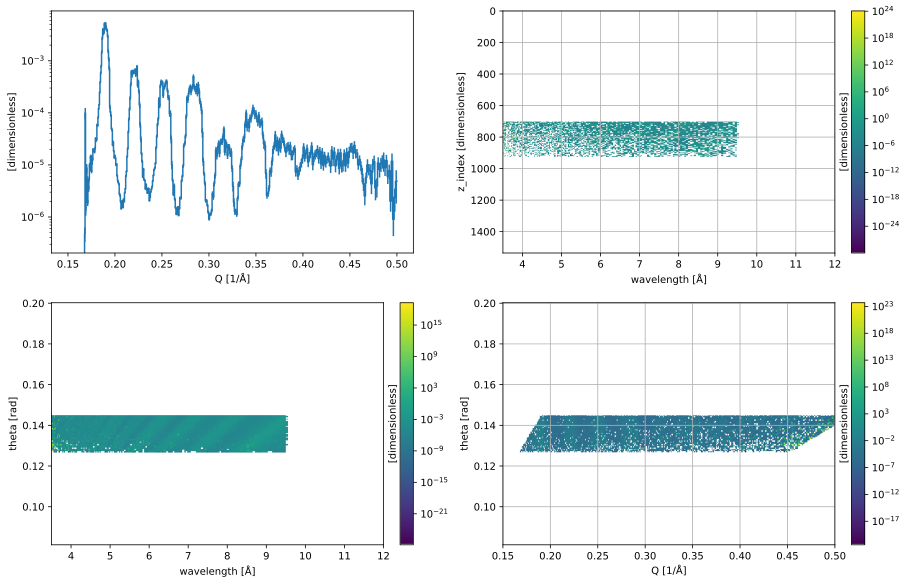

In [18]:
view